# Stage 0: Baseline Constant-σ PINN for Black-Scholes Option Pricing

**Notebook structure:**
- §1: Imports & utilities (BS formulas)
- §2: Data loading & preprocessing (replicates QMD pipeline)
- §3: Train/test split, σ_fixed, r_fixed computation
- §4: Build PINN tensors (collocation, BC, TC, market data)
- §5: PINN architecture (with Fourier features)
- §6: Loss functions (with grad-norm adaptive balancing)
- §7: Training loop
- §8: Validation & diagnostics

Assumes `TSLA_2020_Split_Adjusted.csv` is in the same directory as this notebook.

---
## §1. Imports & Black-Scholes Utilities

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from scipy.stats import norm

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.2.2


In [2]:
import os
import json
from datetime import datetime
import logging

# --- ISOLATION CONFIGURATION ---
# Change this name for each notebook (e.g., "Stage0_Baseline", "Stage0_HighMu")
MODE = "hybrid"         # "physics" or "hybrid"
EXPERIMENT_NAME = "stage0_pinn_RWF_NLP_diff_mu=0.5" 

# Generate a unique ID based on the exact start time
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path(f"runs/{EXPERIMENT_NAME}_{run_id}_{MODE}")
output_dir.mkdir(parents=True, exist_ok=True)

# Set up a dedicated log file for this specific kernel
log_path = output_dir / "session.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(log_path),
        logging.StreamHandler() # Still prints to Jupyter cell
    ]
)

logger = logging.getLogger(__name__)
logger.info(f"Initialized isolated run in: {output_dir}")

2026-03-19 04:36:41,748 [INFO] Initialized isolated run in: runs/stage0_pinn_RWF_NLP_diff_mu=0.5_20260319_043641_hybrid


In [3]:
# ── Black-Scholes formulas ──────────────────────────────────────────

def bs_call_price(S, K, T, r, sigma):
    """
    Vectorized BS European call price in dollar space.
    Used for computing residuals against market data.
    """
    T = np.maximum(T, 1e-4)
    sigma = np.maximum(sigma, 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_call_normalized(m, tau, r, sigma):
    """
    BS call in non-dimensionalized (m, tau) coordinates.
    v_hat(m, tau) = V(S,t) / K  where m = S/K, tau = T - t.
    This is what the PINN learns to approximate.
    """
    tau = np.maximum(tau, 1e-6)
    d1 = (np.log(m) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return m * norm.cdf(d1) - np.exp(-r * tau) * norm.cdf(d2)

---
## §2. Data Loading & Preprocessing

Replicates the R pipeline from `STA-325-option.qmd` (lines 264–296):
1. 1-day lagged daily mean implied volatility
2. Triple Witching week exclusion
3. Moneyness = forward_price / strike_price, restricted to [0.65, 1.35]
4. Remove near-expiration options (< 3 days)
5. Interest rate conversion (percentage → decimal)

In [4]:
# ── Load raw split-adjusted data ────────────────────────────────────
DATA_PATH = "TSLA_2020_Split_Adjusted.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date", "exdate"])
print(f"Loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Loaded: 93,746 rows, 18 columns
Date range: 2020-01-02 → 2020-12-31
Columns: ['date', 'exdate', 'time_to_exp', 'cp_flag', 'strike_price', 'best_bid', 'mid_price', 'best_offer', 'volume', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta', 'forward_price', 'interest_rate', 'dividend_yield']


In [5]:
# ── Step 1: Volume filter & NA removal (safety check) ───────────────
n_before = len(df)
df = df[df["volume"] >= 50].copy()
df = df.dropna(subset=["impl_volatility"])
print(f"After volume/NA filter: {len(df):,} (dropped {n_before - len(df):,})")

After volume/NA filter: 93,746 (dropped 0)


In [6]:
# ── Step 2: 1-day lagged daily mean implied volatility ──────────────
# This matches the QMD's daily_vol_proxy construction.
# We use YESTERDAY's mean IV to avoid look-ahead bias.

daily_vol = (
    df.groupby("date")["impl_volatility"]
    .mean()
    .reset_index()
    .rename(columns={"impl_volatility": "todays_vol_mean"})
    .sort_values("date")
)
daily_vol["daily_vol_proxy"] = daily_vol["todays_vol_mean"].shift(1)
daily_vol["daily_vol_proxy"] = daily_vol["daily_vol_proxy"].ffill().bfill()

df = df.merge(
    daily_vol[["date", "todays_vol_mean", "daily_vol_proxy"]],
    on="date", how="left"
)
print(f"Daily vol proxy range: {df['daily_vol_proxy'].min():.4f} – {df['daily_vol_proxy'].max():.4f}")

Daily vol proxy range: 0.4895 – 1.5155


In [7]:
# ── Step 3: Triple Witching week exclusion ──────────────────────────
n_before = len(df)
triple_witching_ranges = [
    ("2020-03-16", "2020-03-20"),
    ("2020-06-15", "2020-06-19"),
    ("2020-09-14", "2020-09-18"),
    ("2020-12-14", "2020-12-18"),
]
for start, end in triple_witching_ranges:
    mask = (df["date"] >= pd.Timestamp(start)) & (df["date"] <= pd.Timestamp(end))
    df = df[~mask]

print(f"After triple witching: {len(df):,} (dropped {n_before - len(df):,})")

After triple witching: 86,087 (dropped 7,659)


In [8]:
# ── Step 4: Feature engineering & domain filters ────────────────────

# Moneyness
df["moneyness"] = df["forward_price"] / df["strike_price"]

# Domain restriction: moneyness in [0.65, 1.35]
n_before = len(df)
df = df[(df["moneyness"] >= 0.65) & (df["moneyness"] <= 1.35)].copy()
print(f"After moneyness filter: {len(df):,} (dropped {n_before - len(df):,})")

# Remove near-expiration (< 3 days)
n_before = len(df)
df = df[df["time_to_exp"] > (3 / 365)].copy()
print(f"After near-expiry filter: {len(df):,} (dropped {n_before - len(df):,})")

# Interest rate: percentage → decimal
df["interest_rate"] = df["interest_rate"] / 100.0

# Log volume
df["log_volume"] = np.log(df["volume"])

print(f"\nFinal filtered dataset: {len(df):,} observations")
print(f"Moneyness: [{df['moneyness'].min():.4f}, {df['moneyness'].max():.4f}]")
print(f"Time to exp: [{df['time_to_exp'].min():.4f}, {df['time_to_exp'].max():.4f}] years")
print(f"Interest rate: [{df['interest_rate'].min():.4f}, {df['interest_rate'].max():.4f}]")

After moneyness filter: 69,793 (dropped 16,294)
After near-expiry filter: 59,668 (dropped 10,125)

Final filtered dataset: 59,668 observations
Moneyness: [0.6500, 1.3498]
Time to exp: [0.0110, 2.4384] years
Interest rate: [-0.0005, 0.0158]


In [9]:
# ── Step 5: BS theoretical price & residuals ────────────────────────

# BS price using lagged daily vol proxy (matches QMD exactly)
df["bs_theoretical"] = bs_call_price(
    S=df["forward_price"].values,
    K=df["strike_price"].values,
    T=df["time_to_exp"].values,
    r=df["interest_rate"].values,
    sigma=df["daily_vol_proxy"].values,
)

# Market - theory residual
df["residual"] = df["mid_price"] - df["bs_theoretical"]

# Non-dimensionalized prices (what the PINN predicts)
df["v_hat_market"] = df["mid_price"] / df["strike_price"]
df["v_hat_bs"] = df["bs_theoretical"] / df["strike_price"]

print(f"Residual stats (mid - BS):")
print(f"  Mean:   ${df['residual'].mean():.2f}")
print(f"  Median: ${df['residual'].median():.2f}")
print(f"  Std:    ${df['residual'].std():.2f}")

Residual stats (mid - BS):
  Mean:   $-4.41
  Median: $-1.38
  Std:    $11.58


---
## §3. Train/Test Split & Constants

In [10]:
# ── Temporal split: Jan–Oct train, Nov–Dec test ─────────────────────
SPLIT_DATE = "2020-11-01"

train_df = df[df["date"] < pd.Timestamp(SPLIT_DATE)].copy()
test_df  = df[df["date"] >= pd.Timestamp(SPLIT_DATE)].copy()

print(f"Train: {len(train_df):,}  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,}  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")

Train: 47,810  (2020-01-02 → 2020-10-30)
Test:  11,858  (2020-11-02 → 2020-12-31)


In [11]:
# ── σ_fixed: median near-ATM implied vol from training set ──────────
ATM_BAND = (0.95, 1.05)

atm_mask = (train_df["moneyness"] >= ATM_BAND[0]) & (train_df["moneyness"] <= ATM_BAND[1])
atm_options = train_df[atm_mask]

sigma_fixed = float(atm_options["impl_volatility"].median())
r_fixed = float(train_df["interest_rate"].median())

print(f"ATM options in training set: {len(atm_options):,}")
print(f"σ_fixed (median ATM IV):     {sigma_fixed:.4f}")
print(f"  25th pctl: {atm_options['impl_volatility'].quantile(0.25):.4f}")
print(f"  75th pctl: {atm_options['impl_volatility'].quantile(0.75):.4f}")
print(f"r_fixed (median rate):       {r_fixed:.4f}")

ATM options in training set: 13,460
σ_fixed (median ATM IV):     0.7719
  25th pctl: 0.6512
  75th pctl: 0.9288
r_fixed (median rate):       0.0012


In [12]:
# ── Validate: BS RMSE on test set (should match ~$17.23 from report) ─
bs_rmse_test = np.sqrt(np.mean((test_df["mid_price"] - test_df["bs_theoretical"])**2))
print(f"Test set BS RMSE:    ${bs_rmse_test:.2f}")
print(f"Report benchmark:    $17.23")
print(f"Match: {'YES ✓' if abs(bs_rmse_test - 17.23) < 2.0 else 'NO ✗ — investigate'}")

Test set BS RMSE:    $17.23
Report benchmark:    $17.23
Match: YES ✓


---
## §4. Build PINN Tensors

Construct:
1. **Collocation points** $(m, \tau)$ — interior of domain, for PDE residual
2. **Terminal condition** — payoff at $\tau \approx 0$: $\hat{v}(m, 0) = \max(m-1, 0)$
3. **Boundary conditions** — lower ($m_{\min}$) and upper ($m_{\max}$) edges
4. **Market data** — observed $(m, \tau, \hat{v}_{\text{market}})$ for supervised loss

In [13]:
# ── Domain bounds ───────────────────────────────────────────────────
m_min   = float(train_df["moneyness"].min())
m_max   = float(train_df["moneyness"].max())
tau_min = float(train_df["time_to_exp"].min())
tau_max = float(train_df["time_to_exp"].max())

print(f"Domain: m ∈ [{m_min:.4f}, {m_max:.4f}], τ ∈ [{tau_min:.4f}, {tau_max:.4f}]")

Domain: m ∈ [0.6500, 1.3498], τ ∈ [0.0110, 2.4384]


In [14]:
rng = np.random.default_rng(SEED)
N_COLLOC = 20_000

# ── 1. Interior collocation points ──────────────────────────────────
# 70% uniform + 30% concentrated near payoff kink (τ≈0, m≈1)
n_uniform = int(0.7 * N_COLLOC)
n_kink    = N_COLLOC - n_uniform

# Uniform portion
m_colloc_u   = rng.uniform(m_min, m_max, size=n_uniform)
tau_colloc_u = rng.uniform(tau_min, tau_max, size=n_uniform)

# Kink-concentrated portion: τ near 0, m near 1
m_colloc_k   = rng.normal(loc=1.0, scale=0.1, size=n_kink).clip(m_min, m_max)
tau_colloc_k = rng.exponential(scale=0.1, size=n_kink).clip(tau_min, tau_max)

m_colloc   = np.concatenate([m_colloc_u, m_colloc_k]).astype(np.float32)
tau_colloc = np.concatenate([tau_colloc_u, tau_colloc_k]).astype(np.float32)

print(f"Collocation: {len(m_colloc):,} points ({n_uniform} uniform + {n_kink} near kink)")

# ── 2. Terminal condition: τ → 0 (payoff) ───────────────────────────
N_TC = 2000
m_tc   = np.linspace(m_min, m_max, N_TC).astype(np.float32)
tau_tc = np.full(N_TC, 1e-4, dtype=np.float32)
v_tc   = np.maximum(m_tc - 1.0, 0.0).astype(np.float32)

# ── 3. Boundary conditions ──────────────────────────────────────────
N_BC = 1000
tau_bc = np.linspace(tau_min, tau_max, N_BC).astype(np.float32)

# Lower boundary: m = m_min (deep OTM → use BS value for consistency)
m_bc_lo   = np.full(N_BC, m_min, dtype=np.float32)
v_bc_lo   = bs_call_normalized(m_bc_lo, tau_bc, r_fixed, sigma_fixed).astype(np.float32)

# Upper boundary: m = m_max (deep ITM → use BS value)
m_bc_hi   = np.full(N_BC, m_max, dtype=np.float32)
v_bc_hi   = bs_call_normalized(m_bc_hi, tau_bc, r_fixed, sigma_fixed).astype(np.float32)

print(f"Terminal condition: {N_TC} points")
print(f"Boundary conditions: {N_BC} points per edge")

Collocation: 20,000 points (14000 uniform + 6000 near kink)
Terminal condition: 2000 points
Boundary conditions: 1000 points per edge


In [15]:
# ── 4. Pack market data into arrays ─────────────────────────────────

def df_to_arrays(frame):
    """Extract the columns the PINN needs from a DataFrame."""
    return {
        "m":        frame["moneyness"].values.astype(np.float32),
        "tau":      frame["time_to_exp"].values.astype(np.float32),
        "vhat":     frame["v_hat_market"].values.astype(np.float32),
        "vhat_bs":  frame["v_hat_bs"].values.astype(np.float32),
        "mid":      frame["mid_price"].values.astype(np.float32),
        "K":        frame["strike_price"].values.astype(np.float32),
    }

train_arrays = df_to_arrays(train_df)
test_arrays  = df_to_arrays(test_df)

print(f"Train arrays: {len(train_arrays['m']):,} points")
print(f"Test arrays:  {len(test_arrays['m']):,} points")

Train arrays: 47,810 points
Test arrays:  11,858 points


In [16]:
# ── 5. Store everything in a config dict ────────────────────────────

config = {
    "sigma_fixed": sigma_fixed,
    "r_fixed":     r_fixed,
    "m_min":       m_min,
    "m_max":       m_max,
    "tau_min":     tau_min,
    "tau_max":     tau_max,
    "n_train":     len(train_df),
    "n_test":      len(test_df),
    "n_colloc":    N_COLLOC,
    # Benchmarks from report
    "benchmark_rmse_bs":  17.23,
    "benchmark_rmse_gam": 12.57,
    "benchmark_rmse_gp":  9.63,
}

print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  sigma_fixed: 0.771868
  r_fixed: 0.0012
  m_min: 0.65
  m_max: 1.3497625375
  tau_min: 0.010958904109589
  tau_max: 2.4383561643835616
  n_train: 47810
  n_test: 11858
  n_colloc: 20000
  benchmark_rmse_bs: 17.23
  benchmark_rmse_gam: 12.57
  benchmark_rmse_gp: 9.63


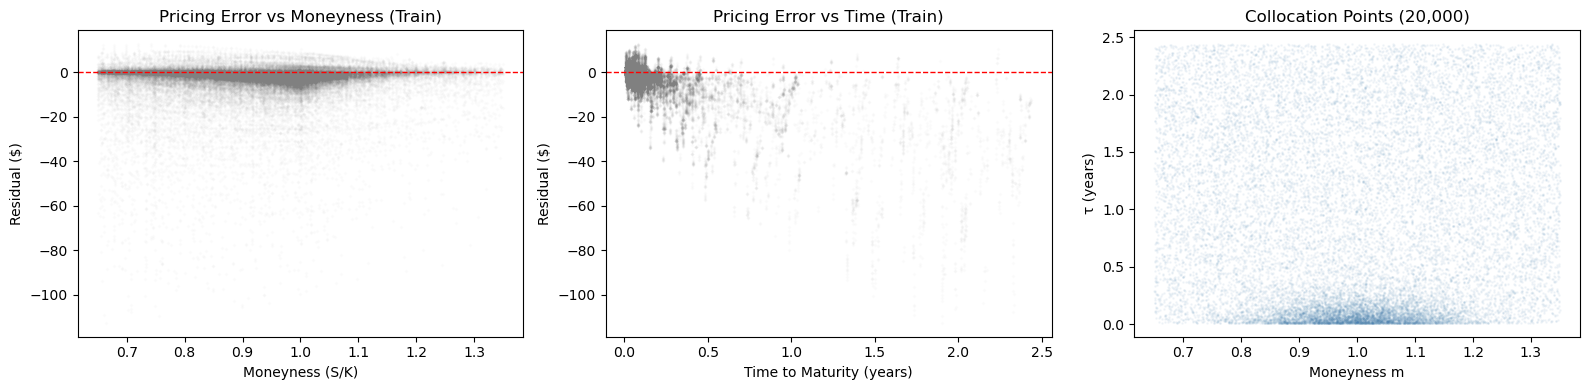


§1–4 complete. Data preparation done.
Proceed to §5 for model definition.


In [17]:
# ── Quick sanity plot: residual vs moneyness (should show the smile) ─

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(train_df["moneyness"], train_df["residual"], alpha=0.02, s=2, c="gray")
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_xlabel("Moneyness (S/K)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title("Pricing Error vs Moneyness (Train)")

axes[1].scatter(train_df["time_to_exp"], train_df["residual"], alpha=0.02, s=2, c="gray")
axes[1].axhline(0, color="red", ls="--", lw=1)
axes[1].set_xlabel("Time to Maturity (years)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Pricing Error vs Time (Train)")

axes[2].scatter(m_colloc, tau_colloc, alpha=0.05, s=1, c="steelblue")
axes[2].set_xlabel("Moneyness m")
axes[2].set_ylabel("τ (years)")
axes[2].set_title(f"Collocation Points ({N_COLLOC:,})")

plt.tight_layout()
plt.show()

print("\n§1–4 complete. Data preparation done.")
print("Proceed to §5 for model definition.")

---
## §5. PINN Architecture

**Fourier Feature Embedding** (Wang et al. §4):  
Maps $(m, \tau) \to [\sin(2\pi B x), \cos(2\pi B x)]$ where $B$ is a fixed random matrix.  
This lets the network represent high-frequency features (the payoff kink at $m=1$)  
that a standard MLP with tanh activations would otherwise smear out.

**Architecture:** Fourier embedding → 4 hidden layers × 64 neurons (tanh) → 1 output

In [18]:
class RWFLinear(nn.Module):
    """
    Random Weight Factorization linear layer (Wang et al. §4.3, Algorithm 2).
    
    Instead of W, we train s and V where W = diag(exp(s)) · V.
    This gives each neuron its own adaptive learning rate:
      effective_lr_k ∝ (exp(s_k)² + ||v_k||²)
    
    Neurons critical for boundary accuracy can develop large s,
    making them more responsive to small BC/TC gradients.
    """
    def __init__(self, in_features, out_features, mu=1.0, sigma=0.1):
        super().__init__()
        # Initialize V with Glorot, same as standard nn.Linear
        self.V = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_normal_(self.V)
        
        # Initialize per-neuron scale: s ~ N(mu, sigma²)
        self.s = nn.Parameter(torch.normal(mu, sigma, size=(out_features,)))
        
        self.bias = nn.Parameter(torch.zeros(out_features))
    
    def forward(self, x):
        # W = diag(exp(s)) · V — exp ensures scale is always positive
        W = torch.diag(torch.exp(self.s)) @ self.V
        return x @ W.T + self.bias


class FourierFeatureEmbedding(nn.Module):
    """
    Random Fourier feature embedding for input coordinates.
    
    Maps x ∈ R^d → [sin(2π·B·x), cos(2π·B·x)] ∈ R^(2·n_features)
    where B is a fixed random matrix ~ N(0, scale²).
    
    The scale parameter controls the frequency range:
      - scale=1.0: good default for normalized inputs
      - higher scale: captures sharper features but risks overfitting
    """
    def __init__(self, in_dim=2, n_features=64, scale=1.0):
        super().__init__()
        B = torch.randn(in_dim, n_features) * scale
        self.register_buffer("B", B)  # fixed, not trainable
        self.out_dim = 2 * n_features
    
    def forward(self, x):
        # x: (N, 2)
        proj = 2 * np.pi * x @ self.B  # (N, n_features)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (N, 2*n_features)


class PricingNet(nn.Module):
    """
    Modified MLP with Fourier features and RWF (Wang et al. §6.4 + §4.3).
    
    Key difference from standard MLP:
      Two encoders U, V embed the input at every hidden layer via gating:
        g(l) = σ(f(l)) ⊙ U + (1 - σ(f(l))) ⊙ V
      
      This keeps input-coordinate gradients alive through all layers,
      preventing the BC/TC gradient vanishing that is a potential cause of our drift problem.
    
    Architecture:
      Fourier(m,τ) → Encoder U, Encoder V (persistent) 
                    → Modified hidden layers × 4 → Linear output
    """
    def __init__(self, hidden_dims=None, fourier_features=64, fourier_scale=1.0,
                 rwf_mu=1.0, rwf_sigma=0.1):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 64, 64, 64]
        
        self.embedding = FourierFeatureEmbedding(
            in_dim=2, n_features=fourier_features, scale=fourier_scale
        )
        embed_dim = self.embedding.out_dim  # 128
        hidden = hidden_dims[0]             # 64 (assumes uniform width)
        
        # ── Two input encoders (Wang et al. Eq. 6.7) ───────────────
        # These project the Fourier-embedded input into hidden space.
        # U and V are evaluated ONCE per forward pass, then reused at every layer.
        self.encoder_U = RWFLinear(embed_dim, hidden, mu=rwf_mu, sigma=rwf_sigma)
        self.encoder_V = RWFLinear(embed_dim, hidden, mu=rwf_mu, sigma=rwf_sigma)
        
        # ── Hidden layers ───────────────────────────────────────────
        # First hidden layer: embed_dim → hidden (takes Fourier features directly)
        # Subsequent layers: hidden → hidden
        self.hidden_layers = nn.ModuleList()
        in_dim = embed_dim
        for h in hidden_dims:
            self.hidden_layers.append(RWFLinear(in_dim, h, mu=rwf_mu, sigma=rwf_sigma))
            in_dim = h
        
        # ── Output layer ───────────────────────────────────────────
        self.output_layer = RWFLinear(hidden, 1, mu=rwf_mu, sigma=rwf_sigma)
        
        self.activation = nn.Tanh()
    
    def forward(self, m, tau):
        if m.dim() == 1:
            m = m.unsqueeze(1)
        if tau.dim() == 1:
            tau = tau.unsqueeze(1)
        
        x = torch.cat([m, tau], dim=1)          # (N, 2)
        x = self.embedding(x)                    # (N, 128)
        
        # ── Compute encoders ONCE (Eq. 6.7) ────────────────────────
        U = self.activation(self.encoder_U(x))   # (N, 64)
        V = self.activation(self.encoder_V(x))   # (N, 64)
        
        # ── Modified MLP forward pass (Eq. 6.8–6.9) ────────────────
        for layer in self.hidden_layers:
            f = layer(x if layer is self.hidden_layers[0] else g)  # Eq. 6.8
            h = self.activation(f)                                  # σ(f(l))
            g = h * U + (1 - h) * V                                # Eq. 6.9: gating
        
        return self.output_layer(g)               # (N, 1), no activation


# ── Instantiate and inspect ─────────────────────────────────────────
model = PricingNet(
    hidden_dims=[64, 64, 64, 64],
    fourier_features=64,
    fourier_scale=1.0,
    rwf_mu=0.5,       # was 1.0
    rwf_sigma=0.1,
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: Modified MLP + RWF + Fourier Features")
print(f"  Fourier: 64 features, scale=1.0")
print(f"  Encoders: U and V (128→64 each)")
print(f"  Hidden: 4 × 64 with gating")
print(f"  RWF: μ=1.0, σ=0.1")
print(f"Total trainable parameters: {n_params:,}")

Architecture: Modified MLP + RWF + Fourier Features
  Fourier: 64 features, scale=1.0
  Encoders: U and V (128→64 each)
  Hidden: 4 × 64 with gating
  RWF: μ=1.0, σ=0.1
Total trainable parameters: 37,698


---
## §6. Loss Functions & Grad-Norm Balancing

**PDE Residual** (BS in $(m, \tau)$ coordinates):
$$\mathcal{R} = \frac{\partial \hat{v}}{\partial \tau} - \frac{1}{2}\sigma^2 m^2 \frac{\partial^2 \hat{v}}{\partial m^2} - r\,m\frac{\partial \hat{v}}{\partial m} + r\,\hat{v} = 0$$

**Grad-norm adaptive balancing** (Wang et al. Algorithm 1):  
Every $N$ steps, set $\hat{\lambda}_i = \frac{\sum_j g_j}{g_i}$ where $g_i = \|\nabla_\theta \mathcal{L}_i\|$,  
then EMA update: $\lambda_i \leftarrow 0.9\,\lambda_i + 0.1\,\hat{\lambda}_i$

In [19]:
def compute_pde_residual(model, m, tau, sigma, r):
    """
    BS PDE residual via automatic differentiation.
    
    R = dv/dτ - 0.5·σ²·m²·d²v/dm² - r·m·dv/dm + r·v
    
    Should be zero everywhere if v satisfies the BS PDE.
    m and tau must have requires_grad=True.
    """
    v = model(m, tau)  # (N, 1)
    ones = torch.ones_like(v)
    
    # First derivatives
    dv_dm, dv_dtau = torch.autograd.grad(
        v, [m, tau], grad_outputs=ones,
        create_graph=True, retain_graph=True
    )
    
    # Second derivative w.r.t. m
    d2v_dm2 = torch.autograd.grad(
        dv_dm, m, grad_outputs=torch.ones_like(dv_dm),
        create_graph=True, retain_graph=True
    )[0]
    
    m_col = m.unsqueeze(1) if m.dim() == 1 else m
    
    residual = (dv_dtau
                - 0.5 * sigma**2 * m_col**2 * d2v_dm2
                - r * m_col * dv_dm
                + r * v)
    return residual


def compute_individual_losses(model, batch, sigma, r, mode="physics"):
    """
    Computes each loss term SEPARATELY (needed for grad-norm balancing).
    
    Returns a dict of {name: loss_tensor} where each tensor retains its
    computation graph for individual gradient computation.
    """
    losses = {}
    
    # ── PDE residual ────────────────────────────────────────────────
    m_c   = batch["m_colloc"].requires_grad_(True)
    tau_c = batch["tau_colloc"].requires_grad_(True)
    residual = compute_pde_residual(model, m_c, tau_c, sigma, r)
    losses["pde"] = torch.mean(residual**2)
    
    # ── Terminal condition ──────────────────────────────────────────
    v_tc_pred = model(batch["m_tc"], batch["tau_tc"])
    losses["tc"] = torch.mean((v_tc_pred - batch["v_tc"].unsqueeze(1))**2)
    
    # ── Boundary conditions ─────────────────────────────────────────
    v_lo_pred = model(batch["m_bc_lo"], batch["tau_bc_lo"])
    v_hi_pred = model(batch["m_bc_hi"], batch["tau_bc_hi"])
    losses["bc"] = 0.5 * (
        torch.mean((v_lo_pred - batch["v_bc_lo"].unsqueeze(1))**2) +
        torch.mean((v_hi_pred - batch["v_bc_hi"].unsqueeze(1))**2)
    )
    
    # ── Data loss (hybrid mode only) ────────────────────────────────
    if mode == "hybrid":
        v_data_pred = model(batch["train_m"], batch["train_tau"])
        losses["data"] = torch.mean((v_data_pred - batch["train_vhat"].unsqueeze(1))**2)
    
    return losses


def compute_grad_norms(model, losses):
    """
    Compute ||∇_θ L_i|| for each loss term.
    Used by the grad-norm balancing scheme.
    """
    grad_norms = {}
    params = [p for p in model.parameters() if p.requires_grad]
    
    for name, loss in losses.items():
        grads = torch.autograd.grad(
            loss, params, retain_graph=True, allow_unused=True
        )
        # Flatten all parameter gradients and compute L2 norm
        total_norm = 0.0
        for g in grads:
            if g is not None:
                total_norm += g.detach().pow(2).sum()
        grad_norms[name] = torch.sqrt(total_norm).item()
    
    return grad_norms


def update_adaptive_weights(current_weights, grad_norms, alpha=0.9):
    """
    Wang et al. Algorithm 1: grad-norm balancing with EMA.
    Added: weight floor for BC/TC to prevent constraint drift.
    """
    total_norm = sum(grad_norms.values())
    new_weights = {}
    
    for name in current_weights:
        if name in grad_norms and grad_norms[name] > 1e-10:
            target = total_norm / grad_norms[name]
        else:
            target = current_weights[name]
        new_weights[name] = alpha * current_weights[name] + (1 - alpha) * target
    
    # ── Safety net: floor on constraint weights ─────────────────────
    # Prevents BC/TC from becoming effectively zero when their losses
    # are well-satisfied. The Modified MLP + RWF should make this
    # rarely active, but it's cheap insurance.
    MIN_CONSTRAINT_WEIGHT = 10.0
    for name in ["tc", "bc"]:
        if name in new_weights:
            new_weights[name] = max(new_weights[name], MIN_CONSTRAINT_WEIGHT)
    
    return new_weights


print("Loss functions and grad-norm balancing defined.")

Loss functions and grad-norm balancing defined.


In [20]:
# if you want to skip training

LOAD_EXISTING = False  # Set to False when you want to retrain

if LOAD_EXISTING:
    checkpoint = torch.load("stage0_model_physics.pt", weights_only=False)
    model = PricingNet(hidden_dims=[64, 64, 64, 64], fourier_features=64, fourier_scale=1.0)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    config = checkpoint["config"]
    adaptive_weights = checkpoint["adaptive_weights"]
    MODE = checkpoint["mode"]
    print(f"Loaded model: mode={MODE}, RMSE=${checkpoint['final_rmse_mkt']:.2f}")
    print("Skip the training cell and go straight to §8.")

---
## §7. Training Loop

In [21]:
def make_batch(train_arrays, rng, device, n_colloc_batch=5000, n_market_batch=8000):
    """
    Sample a fresh mini-batch each iteration.
    Collocation points are resampled; TC/BC use all points.
    """
    batch = {}
    
    # Fresh collocation (same 70/30 split as initial construction)
    n_u = int(0.7 * n_colloc_batch)
    n_k = n_colloc_batch - n_u
    m_u   = rng.uniform(m_min, m_max, n_u)
    tau_u = rng.uniform(tau_min, tau_max, n_u)
    m_k   = rng.normal(1.0, 0.1, n_k).clip(m_min, m_max)
    tau_k = rng.exponential(0.1, n_k).clip(tau_min, tau_max)
    batch["m_colloc"]   = torch.tensor(np.concatenate([m_u, m_k]), dtype=torch.float32).to(device)
    batch["tau_colloc"] = torch.tensor(np.concatenate([tau_u, tau_k]), dtype=torch.float32).to(device)
    
    # TC/BC: use all (they're small)
    batch["m_tc"]     = torch.tensor(m_tc).to(device)
    batch["tau_tc"]   = torch.tensor(tau_tc).to(device)
    batch["v_tc"]     = torch.tensor(v_tc).to(device)
    batch["m_bc_lo"]  = torch.tensor(m_bc_lo).to(device)
    batch["tau_bc_lo"] = torch.tensor(tau_bc).to(device)
    batch["v_bc_lo"]  = torch.tensor(v_bc_lo).to(device)
    batch["m_bc_hi"]  = torch.tensor(m_bc_hi).to(device)
    batch["tau_bc_hi"] = torch.tensor(tau_bc).to(device)
    batch["v_bc_hi"]  = torch.tensor(v_bc_hi).to(device)
    
    # Market data subsample
    n_total = len(train_arrays["m"])
    n_batch = min(n_market_batch, n_total)
    idx = rng.choice(n_total, size=n_batch, replace=False)
    batch["train_m"]    = torch.tensor(train_arrays["m"][idx]).to(device)
    batch["train_tau"]  = torch.tensor(train_arrays["tau"][idx]).to(device)
    batch["train_vhat"] = torch.tensor(train_arrays["vhat"][idx]).to(device)
    
    return batch


@torch.no_grad()
def validate(model, test_arrays, sigma, r, device):
    """Compute test-set metrics."""
    model.eval()
    m_t   = torch.tensor(test_arrays["m"]).to(device)
    tau_t = torch.tensor(test_arrays["tau"]).to(device)
    K_t   = torch.tensor(test_arrays["K"]).to(device)
    mid_t = torch.tensor(test_arrays["mid"]).to(device)
    
    v_pred = model(m_t, tau_t).squeeze()
    
    # vs analytical BS (normalized)
    v_bs = torch.tensor(
        bs_call_normalized(test_arrays["m"], test_arrays["tau"], r, sigma),
        dtype=torch.float32
    ).to(device)
    rmse_bs = torch.sqrt(torch.mean((v_pred - v_bs)**2)).item()
    
    # vs market (dollar)
    price_pred = v_pred * K_t
    rmse_mkt = torch.sqrt(torch.mean((price_pred - mid_t)**2)).item()
    mae_mkt  = torch.mean(torch.abs(price_pred - mid_t)).item()
    
    model.train()
    return {"rmse_bs_norm": rmse_bs, "rmse_mkt": rmse_mkt, "mae_mkt": mae_mkt}


print("Batch sampler and validation function defined.")

Batch sampler and validation function defined.


In [23]:
# ══════════════════════════════════════════════════════════════════════
# TRAINING CONFIGURATION — edit these as needed
# ══════════════════════════════════════════════════════════════════════

EPOCHS = 12000
LR = 1e-3
N_COLLOC_BATCH = 5000
N_MARKET_BATCH = 8000    # only used in hybrid mode
GRAD_NORM_FREQ = 1000    # update adaptive weights every N steps
GRAD_NORM_ALPHA = 0.9    # EMA smoothing for weight updates
LOG_EVERY = 500
VAL_EVERY = 1000



In [24]:
# ══════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════

# Reset model for fresh training
model = PricingNet(
    hidden_dims=[64, 64, 64, 64],
    fourier_features=64,
    fourier_scale=1.0,
    rwf_mu=0.5,       # was 1.0
    rwf_sigma=0.1,
)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR * 0.01
)

# Adaptive weights — start at 1.0 for all terms
loss_names = ["pde", "tc", "bc"] + (["data"] if MODE == "hybrid" else [])
adaptive_weights = {name: 1.0 for name in loss_names}

rng_train = np.random.default_rng(SEED)
sigma = config["sigma_fixed"]
r = config["r_fixed"]

# History tracking
history = {"epoch": [], "L_total": []}
for name in loss_names:
    history[f"L_{name}"] = []
    history[f"w_{name}"] = []
history["rmse_bs_norm"] = []
history["rmse_mkt"] = []
history["val_epoch"] = []

best_val = float("inf")
best_state = None

print(f"Training: mode={MODE}, epochs={EPOCHS}, lr={LR}")
print(f"Adaptive loss balancing: grad-norm every {GRAD_NORM_FREQ} steps, α={GRAD_NORM_ALPHA}")
print(f"Loss terms: {loss_names}")
print("=" * 70)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    
    # ── Sample batch ────────────────────────────────────────────────
    batch = make_batch(train_arrays, rng_train, device,
                       n_colloc_batch=N_COLLOC_BATCH,
                       n_market_batch=N_MARKET_BATCH)
    
    # ── Compute individual losses ───────────────────────────────────
    individual_losses = compute_individual_losses(model, batch, sigma, r, mode=MODE)
    
    # ── Grad-norm weight update ─────────────────────────────────────
    if epoch % GRAD_NORM_FREQ == 0 or epoch == 1:
        grad_norms = compute_grad_norms(model, individual_losses)
        adaptive_weights = update_adaptive_weights(
            adaptive_weights, grad_norms, alpha=GRAD_NORM_ALPHA
        )
    
    # ── Weighted total loss ─────────────────────────────────────────
    loss_total = sum(
        adaptive_weights[name] * individual_losses[name]
        for name in individual_losses
    )
    
    # ── Backward + step ─────────────────────────────────────────────
    optimizer.zero_grad()
    loss_total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    
    # ── Logging ─────────────────────────────────────────────────────
    if epoch % LOG_EVERY == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        parts = [f"Ep {epoch:5d}/{EPOCHS}"]
        parts.append(f"L={loss_total.item():.2e}")
        for name in loss_names:
            parts.append(f"{name}={individual_losses[name].item():.2e}")
            parts.append(f"w={adaptive_weights[name]:.2f}")
        parts.append(f"lr={lr_now:.1e}")
        print(" | ".join(parts))
    
    # ── Record history ──────────────────────────────────────────────
    history["epoch"].append(epoch)
    history["L_total"].append(loss_total.item())
    for name in loss_names:
        history[f"L_{name}"].append(individual_losses[name].item())
        history[f"w_{name}"].append(adaptive_weights[name])
    
    # ── Validation ──────────────────────────────────────────────────
    if epoch % VAL_EVERY == 0 or epoch == EPOCHS:
        metrics = validate(model, test_arrays, sigma, r, device)
        history["val_epoch"].append(epoch)
        history["rmse_bs_norm"].append(metrics["rmse_bs_norm"])
        history["rmse_mkt"].append(metrics["rmse_mkt"])
        
        key = "rmse_bs_norm" if MODE == "physics" else "rmse_mkt"
        val = metrics[key]
        print(f"  [VAL] RMSE vs BS (norm): {metrics['rmse_bs_norm']:.6f} "
              f"| RMSE vs Market ($): {metrics['rmse_mkt']:.2f} "
              f"| MAE vs Market ($): {metrics['mae_mkt']:.2f}")
        
        if val < best_val:
            best_val = val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ** New best {key}: {val:.6f}")

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.1f}s")

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"Restored best model (val {key}: {best_val:.6f})")

Training: mode=hybrid, epochs=12000, lr=0.001
Adaptive loss balancing: grad-norm every 1000 steps, α=0.9
Loss terms: ['pde', 'tc', 'bc', 'data']
Ep     1/12000 | L=2.46e+05 | pde=2.10e+05 | w=1.00 | tc=2.22e+00 | w=2720.84 | bc=4.88e+00 | w=3833.07 | data=2.74e+00 | w=3790.30 | lr=1.0e-03
Ep   500/12000 | L=2.07e+01 | pde=5.87e+00 | w=1.00 | tc=2.07e-03 | w=2720.84 | bc=3.42e-04 | w=3833.07 | data=2.09e-03 | w=3790.30 | lr=1.0e-03
Ep  1000/12000 | L=8.31e+00 | pde=1.56e+00 | w=1.00 | tc=8.13e-04 | w=2539.49 | bc=1.52e-04 | w=3876.48 | data=1.17e-03 | w=3514.14 | lr=9.8e-04
  [VAL] RMSE vs BS (norm): 0.028803 | RMSE vs Market ($): 17.51 | MAE vs Market ($): 14.71
  ** New best rmse_mkt: 17.510042
Ep  1500/12000 | L=3.01e+00 | pde=5.97e-01 | w=1.00 | tc=1.56e-04 | w=2539.49 | bc=2.52e-05 | w=3876.48 | data=5.47e-04 | w=3514.14 | lr=9.6e-04
Ep  2000/12000 | L=3.31e+00 | pde=7.73e-01 | w=1.00 | tc=1.40e-04 | w=2391.19 | bc=1.07e-04 | w=3726.02 | data=5.48e-04 | w=3281.89 | lr=9.3e-04
  [VA

In [25]:
# --- ISOLATED SAVING ---
# 1. Save the trained model weights
torch.save(model.state_dict(), output_dir / "model_weights.pth")

# 2. Save the loss history (the 'history' dict from your training loop)
with open(output_dir / "loss_history.json", "w") as f:
    # Convert any tensors in history to lists/floats for JSON compatibility
    clean_history = {k: [float(x) if torch.is_tensor(x) else x for x in v] 
                     for k, v in history.items()}
    json.dump(clean_history, f, indent=4)

# 3. Save any final plots (if applicable)
# plt.savefig(output_dir / "loss_curve.png")

logger.info(f"Successfully saved all run data to {output_dir}")

2026-03-19 05:54:20,273 [INFO] Successfully saved all run data to runs/stage0_pinn_RWF_NLP_diff_mu=0.5_20260319_043641_hybrid


---
## §8. Diagnostics & Visualization

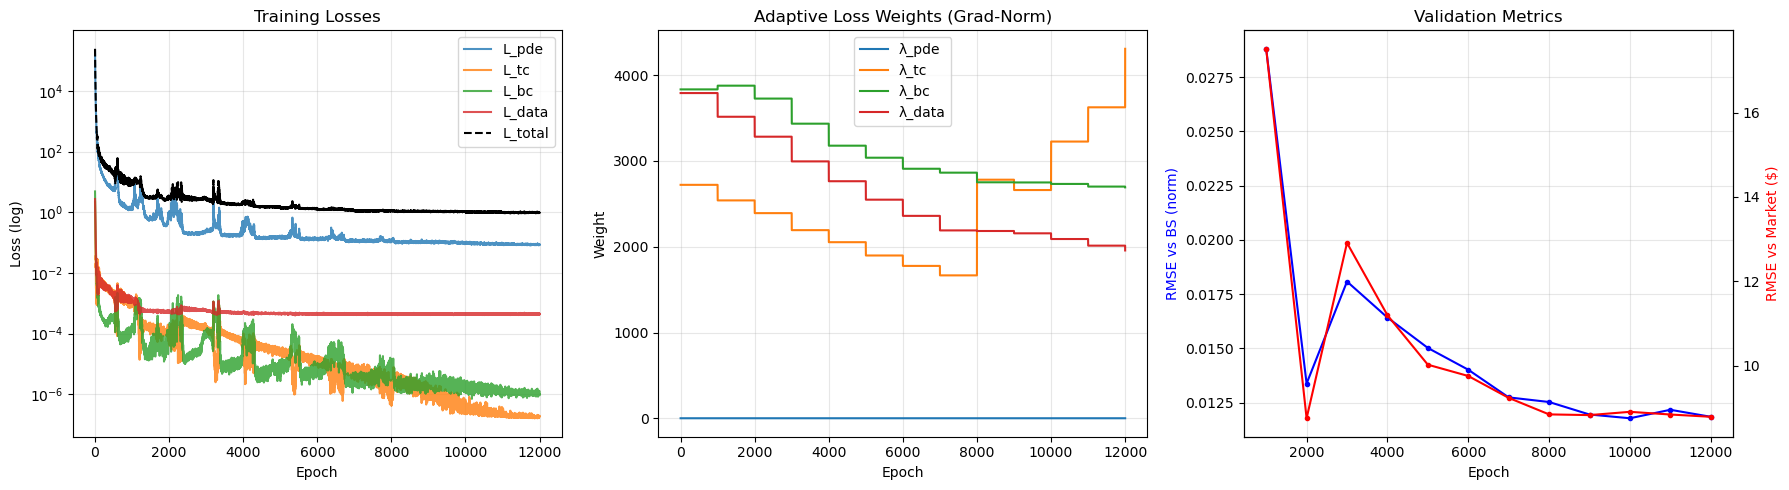

In [26]:
# ── 8a. Loss & weight history ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
epochs_h = history["epoch"]
for name in loss_names:
    axes[0].semilogy(epochs_h, history[f"L_{name}"], label=f"L_{name}", alpha=0.8)
axes[0].semilogy(epochs_h, history["L_total"], label="L_total", color="black", ls="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log)")
axes[0].set_title("Training Losses")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Adaptive weights
for name in loss_names:
    axes[1].plot(epochs_h, history[f"w_{name}"], label=f"λ_{name}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weight")
axes[1].set_title("Adaptive Loss Weights (Grad-Norm)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Validation metrics
val_ep = history["val_epoch"]
axes[2].plot(val_ep, history["rmse_bs_norm"], "b.-", label="RMSE vs BS (norm)")
ax2 = axes[2].twinx()
ax2.plot(val_ep, history["rmse_mkt"], "r.-", label="RMSE vs Market ($)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE vs BS (norm)", color="blue")
ax2.set_ylabel("RMSE vs Market ($)", color="red")
axes[2].set_title("Validation Metrics")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

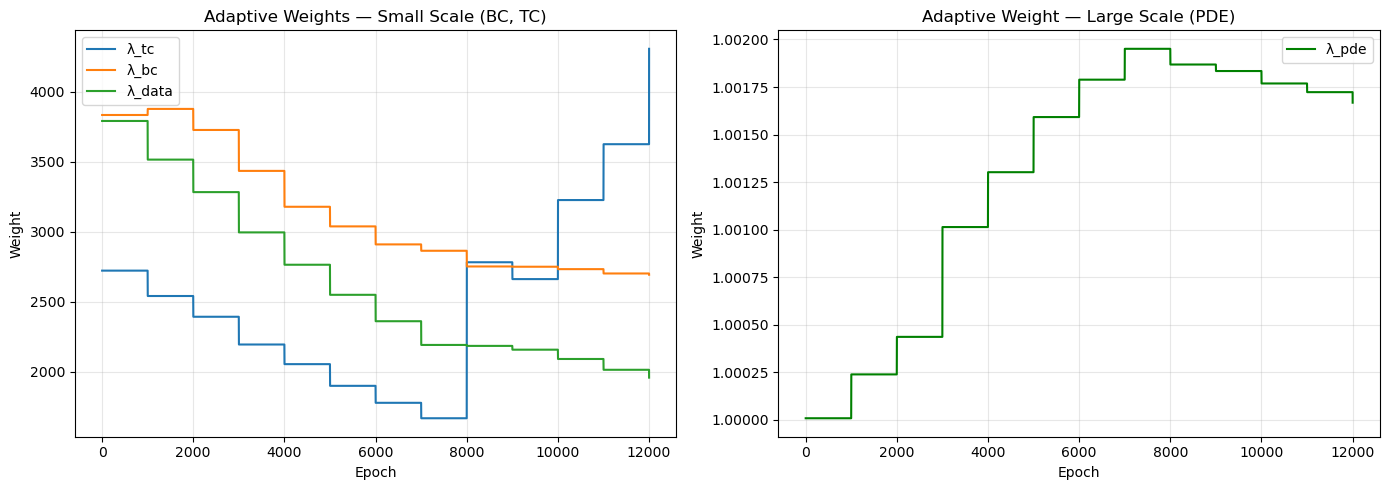

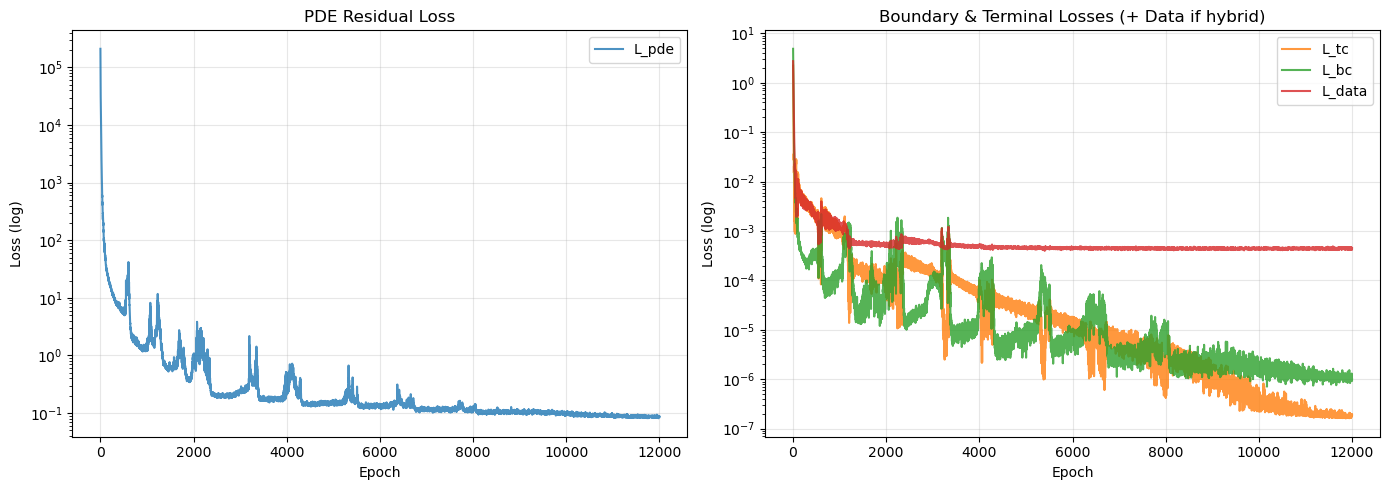

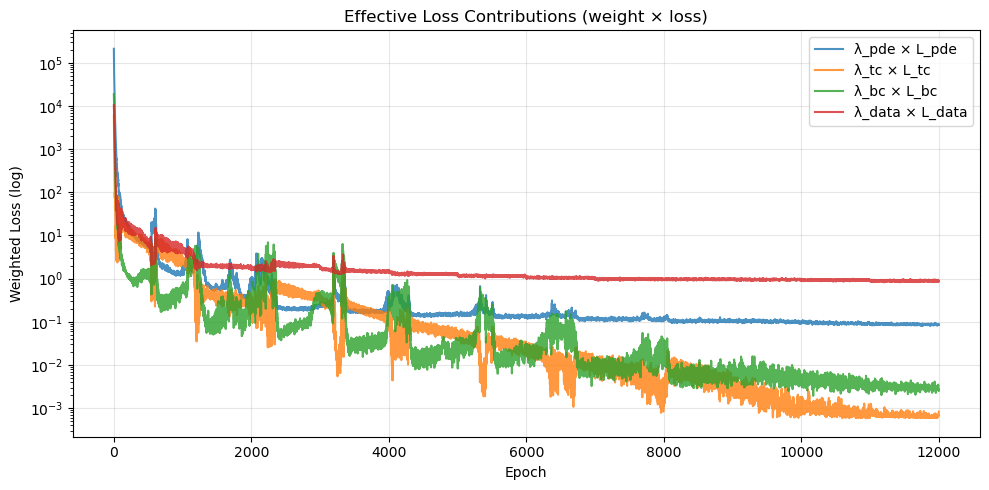

In [27]:
# ── 8a-bis. Adaptive weights: separate scales ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_h = history["epoch"]

# Left: small-scale weights (PDE, TC, and DATA if hybrid)
small_names = [n for n in loss_names if n != "pde"]
for name in small_names:
    axes[0].plot(epochs_h, history[f"w_{name}"], label=f"λ_{name}", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weight")
axes[0].set_title("Adaptive Weights — Small Scale (BC, TC)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: large-scale weight (BC)
axes[1].plot(epochs_h, history[f"w_pde"], label="λ_pde", color="green", linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weight")
axes[1].set_title("Adaptive Weight — Large Scale (PDE)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Also: separate loss curves at different scales ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDE loss (dominates early)
axes[0].semilogy(epochs_h, history["L_pde"], label="L_pde", color="tab:blue", alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log)")
axes[0].set_title("PDE Residual Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: TC + BC losses (much smaller scale)
axes[1].semilogy(epochs_h, history["L_tc"], label="L_tc", color="tab:orange", alpha=0.8)
axes[1].semilogy(epochs_h, history["L_bc"], label="L_bc", color="tab:green", alpha=0.8)
if "L_data" in history:
    axes[1].semilogy(epochs_h, history["L_data"], label="L_data", color="tab:red", alpha=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log)")
axes[1].set_title("Boundary & Terminal Losses (+ Data if hybrid)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Weighted losses: what the optimizer actually sees ───────────────

fig, ax = plt.subplots(figsize=(10, 5))

for name in loss_names:
    weighted = [w * l for w, l in zip(history[f"w_{name}"], history[f"L_{name}"])]
    ax.semilogy(epochs_h, weighted, label=f"λ_{name} × L_{name}", alpha=0.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted Loss (log)")
ax.set_title("Effective Loss Contributions (weight × loss)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

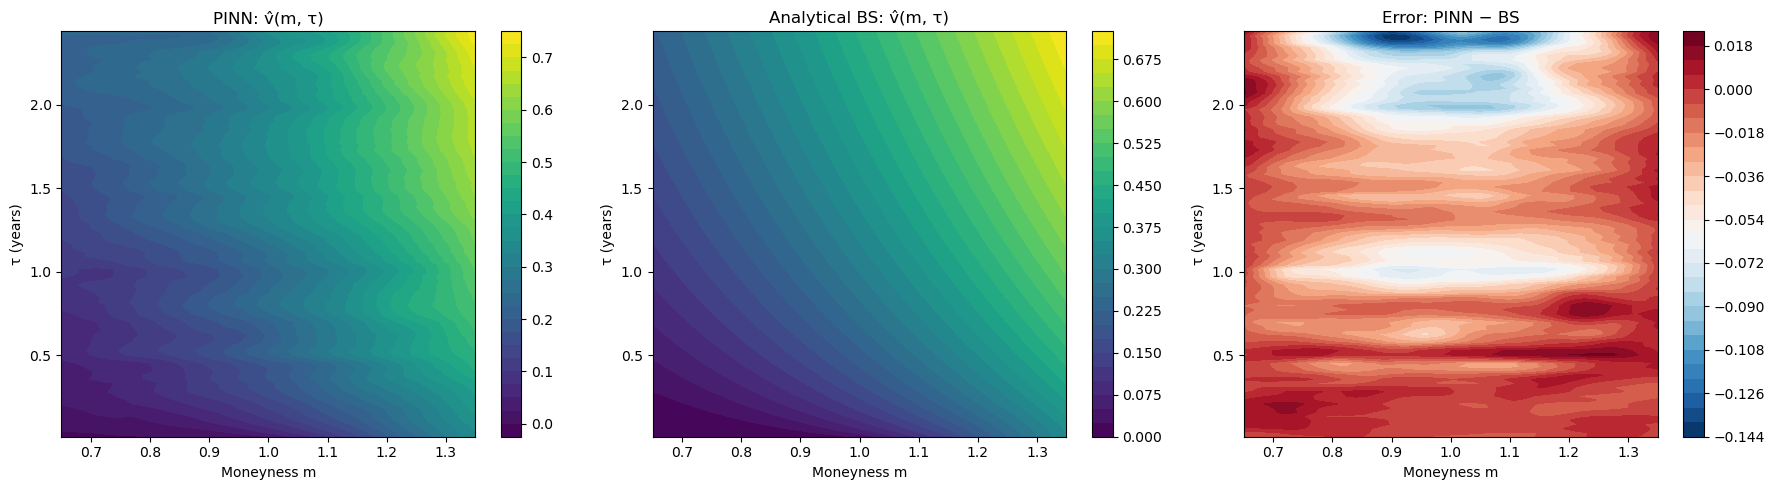

Max absolute error (PINN vs BS, normalized): 0.142526


In [28]:
# ── 8b. Solution surface: PINN vs BS vs Error ───────────────────────

model.eval()
m_grid   = np.linspace(m_min, m_max, 100)
tau_grid = np.linspace(tau_min, tau_max, 100)
M_g, TAU_g = np.meshgrid(m_grid, tau_grid)
m_flat   = M_g.flatten().astype(np.float32)
tau_flat = TAU_g.flatten().astype(np.float32)

with torch.no_grad():
    v_pred = model(
        torch.tensor(m_flat).to(device),
        torch.tensor(tau_flat).to(device)
    ).squeeze().cpu().numpy()

v_bs_grid = bs_call_normalized(m_flat, tau_flat, r, sigma)
v_err = v_pred - v_bs_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c0 = axes[0].contourf(M_g, TAU_g, v_pred.reshape(M_g.shape), levels=30, cmap="viridis")
axes[0].set_title("PINN: v̂(m, τ)")
axes[0].set_xlabel("Moneyness m")
axes[0].set_ylabel("τ (years)")
plt.colorbar(c0, ax=axes[0])

c1 = axes[1].contourf(M_g, TAU_g, v_bs_grid.reshape(M_g.shape), levels=30, cmap="viridis")
axes[1].set_title("Analytical BS: v̂(m, τ)")
axes[1].set_xlabel("Moneyness m")
axes[1].set_ylabel("τ (years)")
plt.colorbar(c1, ax=axes[1])

c2 = axes[2].contourf(M_g, TAU_g, v_err.reshape(M_g.shape), levels=30, cmap="RdBu_r")
axes[2].set_title("Error: PINN − BS")
axes[2].set_xlabel("Moneyness m")
axes[2].set_ylabel("τ (years)")
plt.colorbar(c2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Max absolute error (PINN vs BS, normalized): {np.max(np.abs(v_err)):.6f}")

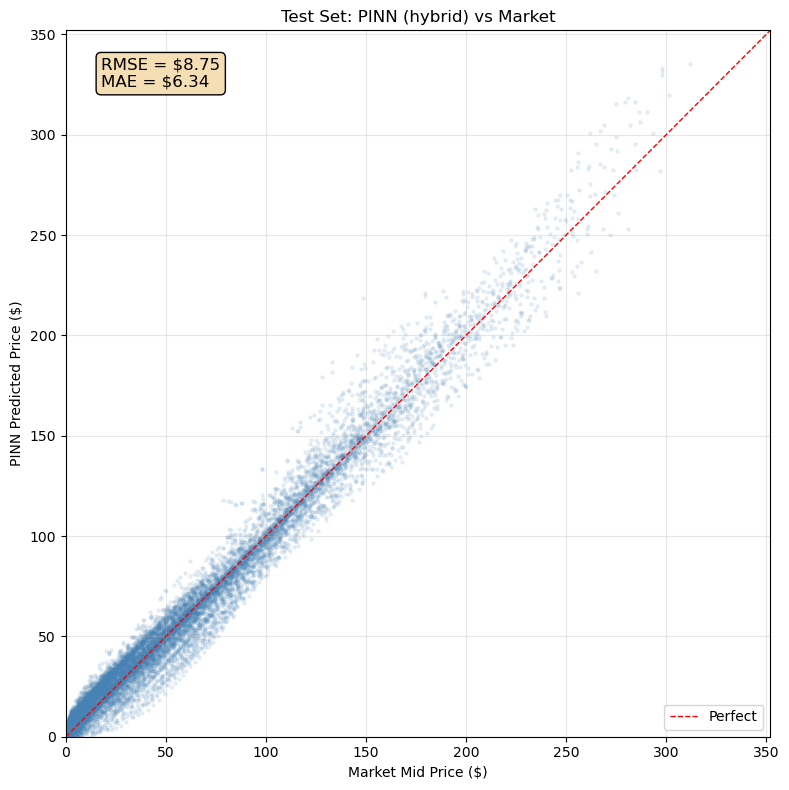

In [29]:
# ── 8c. Test set scatter: PINN predicted price vs market ────────────

with torch.no_grad():
    m_test_t   = torch.tensor(test_arrays["m"]).to(device)
    tau_test_t = torch.tensor(test_arrays["tau"]).to(device)
    v_pred_test = model(m_test_t, tau_test_t).squeeze().cpu().numpy()

price_pred = v_pred_test * test_arrays["K"]
mid_test = test_arrays["mid"]

rmse_final = np.sqrt(np.mean((price_pred - mid_test)**2))
mae_final  = np.mean(np.abs(price_pred - mid_test))

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(mid_test, price_pred, alpha=0.1, s=5, c="steelblue")
lims = [0, max(mid_test.max(), price_pred.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1, label="Perfect")
ax.set_xlabel("Market Mid Price ($)")
ax.set_ylabel("PINN Predicted Price ($)")
ax.set_title(f"Test Set: PINN ({MODE}) vs Market")
ax.text(0.05, 0.92, f"RMSE = ${rmse_final:.2f}\nMAE = ${mae_final:.2f}",
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round", facecolor="wheat"))
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

In [30]:
# ── 8d. Final summary ───────────────────────────────────────────────

print("=" * 60)
print(f"STAGE 0 RESULTS ({MODE} mode)")
print("=" * 60)
print(f"PINN RMSE vs market (test, $):  ${rmse_final:.2f}")
print(f"PINN MAE  vs market (test, $):  ${mae_final:.2f}")
print(f"")
print(f"Benchmarks from report:")
print(f"  Black-Scholes: ${config['benchmark_rmse_bs']}")
print(f"  GAM:           ${config['benchmark_rmse_gam']}")
print(f"  laGP:          ${config['benchmark_rmse_gp']}")
print("=" * 60)

STAGE 0 RESULTS (hybrid mode)
PINN RMSE vs market (test, $):  $8.75
PINN MAE  vs market (test, $):  $6.34

Benchmarks from report:
  Black-Scholes: $17.23
  GAM:           $12.57
  laGP:          $9.63


In [31]:
# ── Save model checkpoint ───────────────────────────────────────────
SAVE_PATH = f"stage0_model_RWF_NLP_mu=0.5{MODE}.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": config,
    "mode": MODE,
    "final_rmse_mkt": rmse_final,
    "adaptive_weights": adaptive_weights,
}, SAVE_PATH)
print(f"Saved checkpoint to {SAVE_PATH}")

Saved checkpoint to stage0_model_RWF_NLP_mu=0.5hybrid.pt


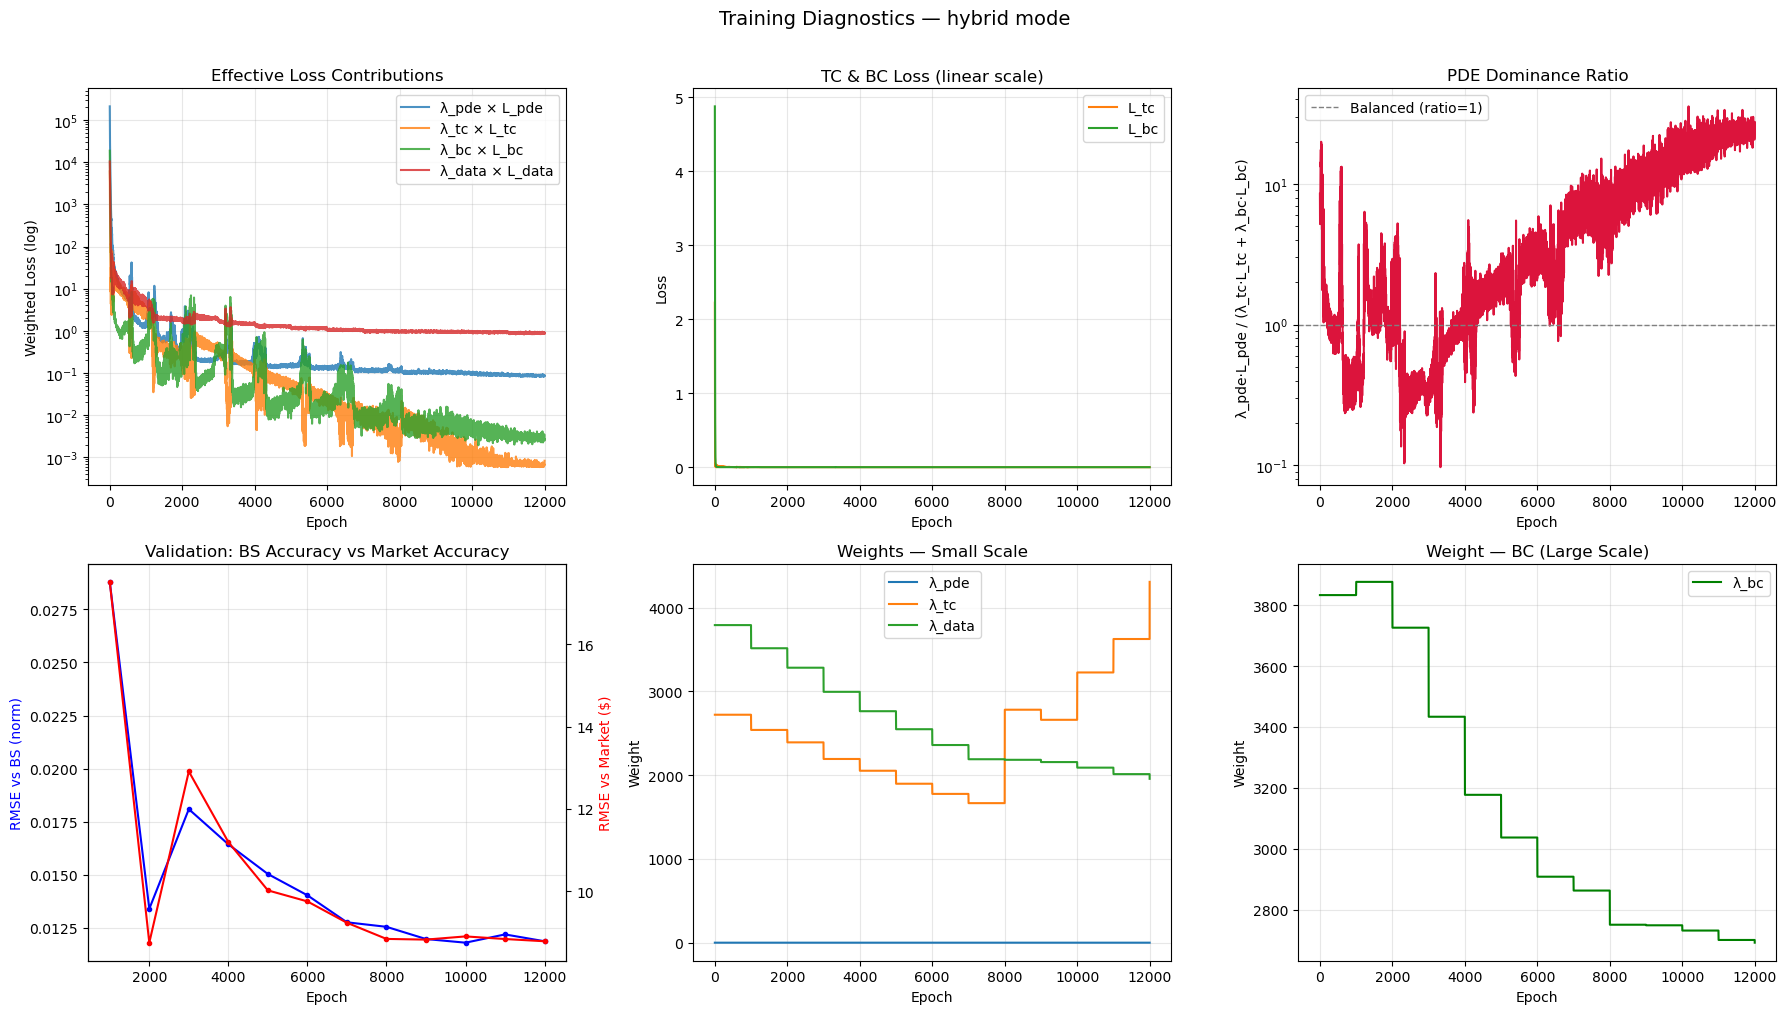


Diagnostic summary at key epochs:
 Epoch |      L_pde |       L_tc |       L_bc |     wL_pde |      wL_tc |      wL_bc |    ratio
------------------------------------------------------------------------------------------
     1 |   2.10e+05 |   2.22e+00 |   4.88e+00 |   2.10e+05 |   6.05e+03 |   1.87e+04 |      8.5
   500 |   5.87e+00 |   2.07e-03 |   3.42e-04 |   5.87e+00 |   5.62e+00 |   1.31e+00 |      0.8
  1000 |   1.56e+00 |   8.13e-04 |   1.52e-04 |   1.56e+00 |   2.06e+00 |   5.89e-01 |      0.6
  2000 |   7.73e-01 |   1.40e-04 |   1.07e-04 |   7.74e-01 |   3.35e-01 |   3.98e-01 |      1.1
  3000 |   2.21e-01 |   1.58e-04 |   7.83e-05 |   2.21e-01 |   3.47e-01 |   2.69e-01 |      0.4
  5000 |   1.58e-01 |   2.52e-05 |   1.01e-05 |   1.58e-01 |   4.77e-02 |   3.07e-02 |      2.0
  7000 |   1.22e-01 |   7.22e-06 |   3.66e-06 |   1.22e-01 |   1.20e-02 |   1.05e-02 |      5.4
 10000 |   9.28e-02 |   3.31e-07 |   1.56e-06 |   9.29e-02 |   1.07e-03 |   4.27e-03 |     17.4


In [32]:
# ── Diagnostics: Why does RMSE degrade? ─────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_h = history["epoch"]

# ── 1. Weighted losses (what optimizer actually sees) ───────────────
for name in loss_names:
    weighted = [w * l for w, l in zip(history[f"w_{name}"], history[f"L_{name}"])]
    axes[0, 0].semilogy(epochs_h, weighted, label=f"λ_{name} × L_{name}", alpha=0.8)
axes[0, 0].set_title("Effective Loss Contributions")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Weighted Loss (log)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── 2. BC/TC raw loss zoomed in ─────────────────────────────────────
axes[0, 1].plot(epochs_h, history["L_tc"], label="L_tc", color="tab:orange")
axes[0, 1].plot(epochs_h, history["L_bc"], label="L_bc", color="tab:green")
axes[0, 1].set_title("TC & BC Loss (linear scale)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── 3. Ratio: PDE weighted loss / (TC+BC weighted loss) ─────────────
pde_w = [w * l for w, l in zip(history["w_pde"], history["L_pde"])]
tc_w  = [w * l for w, l in zip(history["w_tc"],  history["L_tc"])]
bc_w  = [w * l for w, l in zip(history["w_bc"],  history["L_bc"])]
ratio = [p / max(t + b, 1e-12) for p, t, b in zip(pde_w, tc_w, bc_w)]
axes[0, 2].semilogy(epochs_h, ratio, color="crimson")
axes[0, 2].axhline(1.0, color="gray", ls="--", lw=1, label="Balanced (ratio=1)")
axes[0, 2].set_title("PDE Dominance Ratio")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("λ_pde·L_pde / (λ_tc·L_tc + λ_bc·L_bc)")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# ── 4. Validation: both metrics together ────────────────────────────
val_ep = history["val_epoch"]
ax_bs = axes[1, 0]
ax_mkt = ax_bs.twinx()
ax_bs.plot(val_ep, history["rmse_bs_norm"], "b.-", label="RMSE vs BS (norm)")
ax_mkt.plot(val_ep, history["rmse_mkt"], "r.-", label="RMSE vs Market ($)")
ax_bs.set_xlabel("Epoch")
ax_bs.set_ylabel("RMSE vs BS (norm)", color="blue")
ax_mkt.set_ylabel("RMSE vs Market ($)", color="red")
axes[1, 0].set_title("Validation: BS Accuracy vs Market Accuracy")
ax_bs.grid(True, alpha=0.3)

# ── 5. Weight trajectories (separate scales) ────────────────────────
for name in loss_names:
    if name != "bc":
        axes[1, 1].plot(epochs_h, history[f"w_{name}"], label=f"λ_{name}")
axes[1, 1].set_title("Weights — Small Scale")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Weight")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(epochs_h, history[f"w_bc"], label="λ_bc", color="green")
axes[1, 2].set_title("Weight — BC (Large Scale)")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_ylabel("Weight")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"Training Diagnostics — {MODE} mode", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Numerical summary at key epochs ─────────────────────────────────
print("\nDiagnostic summary at key epochs:")
print(f"{'Epoch':>6} | {'L_pde':>10} | {'L_tc':>10} | {'L_bc':>10} | "
      f"{'wL_pde':>10} | {'wL_tc':>10} | {'wL_bc':>10} | {'ratio':>8}")
print("-" * 90)
for target_ep in [1, 500, 1000, 2000, 3000, 5000, 7000, 10000]:
    if target_ep > len(epochs_h):
        continue
    i = target_ep - 1
    wl_pde = history["w_pde"][i] * history["L_pde"][i]
    wl_tc  = history["w_tc"][i]  * history["L_tc"][i]
    wl_bc  = history["w_bc"][i]  * history["L_bc"][i]
    r = wl_pde / max(wl_tc + wl_bc, 1e-12)
    print(f"{target_ep:>6} | {history['L_pde'][i]:>10.2e} | {history['L_tc'][i]:>10.2e} | "
          f"{history['L_bc'][i]:>10.2e} | {wl_pde:>10.2e} | {wl_tc:>10.2e} | "
          f"{wl_bc:>10.2e} | {r:>8.1f}")